## ⚡ Finetune Forecasting with EnergyTTM

This notebook performs **Fine-tuned energy forecasting** using a pretrained **EnergyTTM** model with fine-tuning.

### 🔹 Experimental Setup

- **Context Length:** `168` time steps (past 7 days of hourly data)  
- **Forecast Horizon:** `24` time steps (next 24 hours)    
- **Data:** Unseen buildings for evaluating generalization  




In [139]:
import os
import random 
import math 
import tempfile 
import torch 
import pickle 
import logging 
import warnings
import json
import torch.nn as nn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np 
import pandas as pd
from transformers import  set_seed
from torch.utils.data import ConcatDataset, Dataset, DataLoader
from tsfm_public.models.tinytimemixer.configuration_tinytimemixer import TinyTimeMixerConfig
from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction

warnings.filterwarnings("ignore")
SEED = 42
set_seed(SEED)


In [140]:
df = pd.read_csv("../Dataset/Forecasting/sample_building_ashrae.csv")

In [141]:
df.head()

,timestamp,meter_reading
0,2016-01-01 00:00:00,3.4
1,2016-01-01 01:00:00,1.8
2,2016-01-01 02:00:00,2.2
3,2016-01-01 03:00:00,2.2
4,2016-01-01 04:00:00,2.3


In [142]:

# Set index
df.set_index("timestamp", inplace=True)
df.index = pd.to_datetime(df.index)
# Ensure numeric
df["meter_reading"] = pd.to_numeric(df["meter_reading"], errors="coerce")


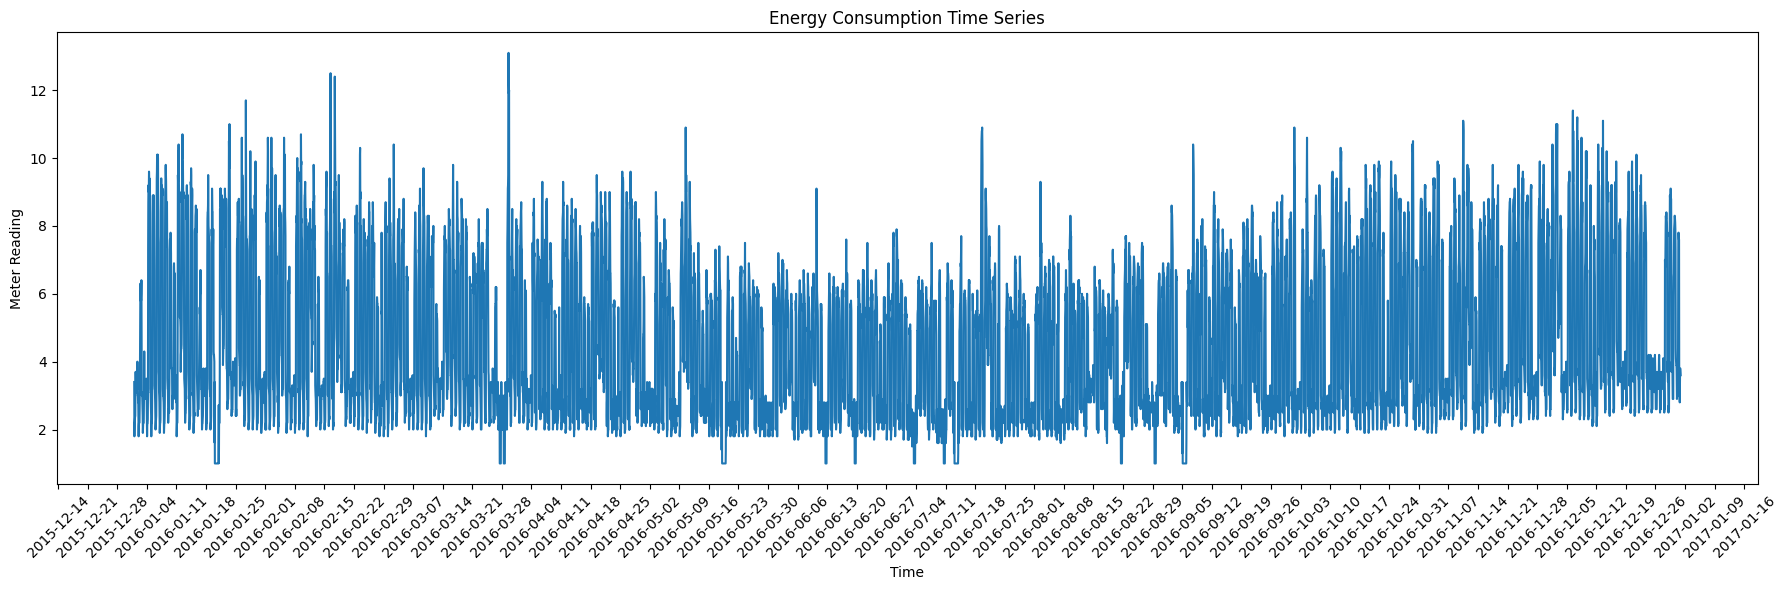

In [143]:
import matplotlib.dates as mdates

plt.figure(figsize=(18, 6))
plt.plot(df.index, df["meter_reading"])

ax = plt.gca()

# Major ticks every week (Monday)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=45)
plt.title("Energy Consumption Time Series")
plt.xlabel("Time")
plt.ylabel("Meter Reading")
plt.tight_layout()
plt.show()

In [144]:
print(df.isna().sum())
df.describe()

meter_reading    0
dtype: int64


,meter_reading
count,8784.000000
mean,4.565478
std,2.436957
min,1.000000
25%,2.500000
50%,3.400000
75%,6.600000
max,13.100000


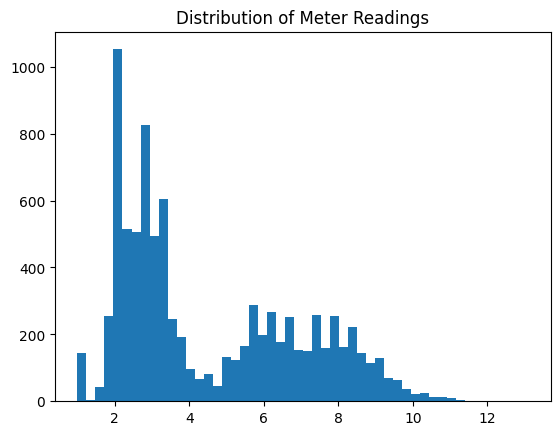

In [145]:
plt.figure()
plt.hist(df["meter_reading"], bins=50)
plt.title("Distribution of Meter Readings")
plt.show()

In [146]:
split_idx = int(len(df) * 0.75)

train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 6588
Test size: 2196


### Moving Average

In [147]:
window = 168  # weekly seasonality for hourly data

history = list(train["meter_reading"])
predictions = []

for t in range(len(test)):
    # Forecast using last 168 observations
    yhat = np.mean(history[-window:])
    predictions.append(yhat)
    
    # Update history with TRUE observation (important!)
    history.append(test["meter_reading"].iloc[t])

In [148]:
mae = mean_absolute_error(test["meter_reading"], predictions)
rmse = np.sqrt(mean_squared_error(test["meter_reading"], predictions))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 2.4725
RMSE: 2.6656


In [149]:
print(test.index.dtype)

datetime64[ns]


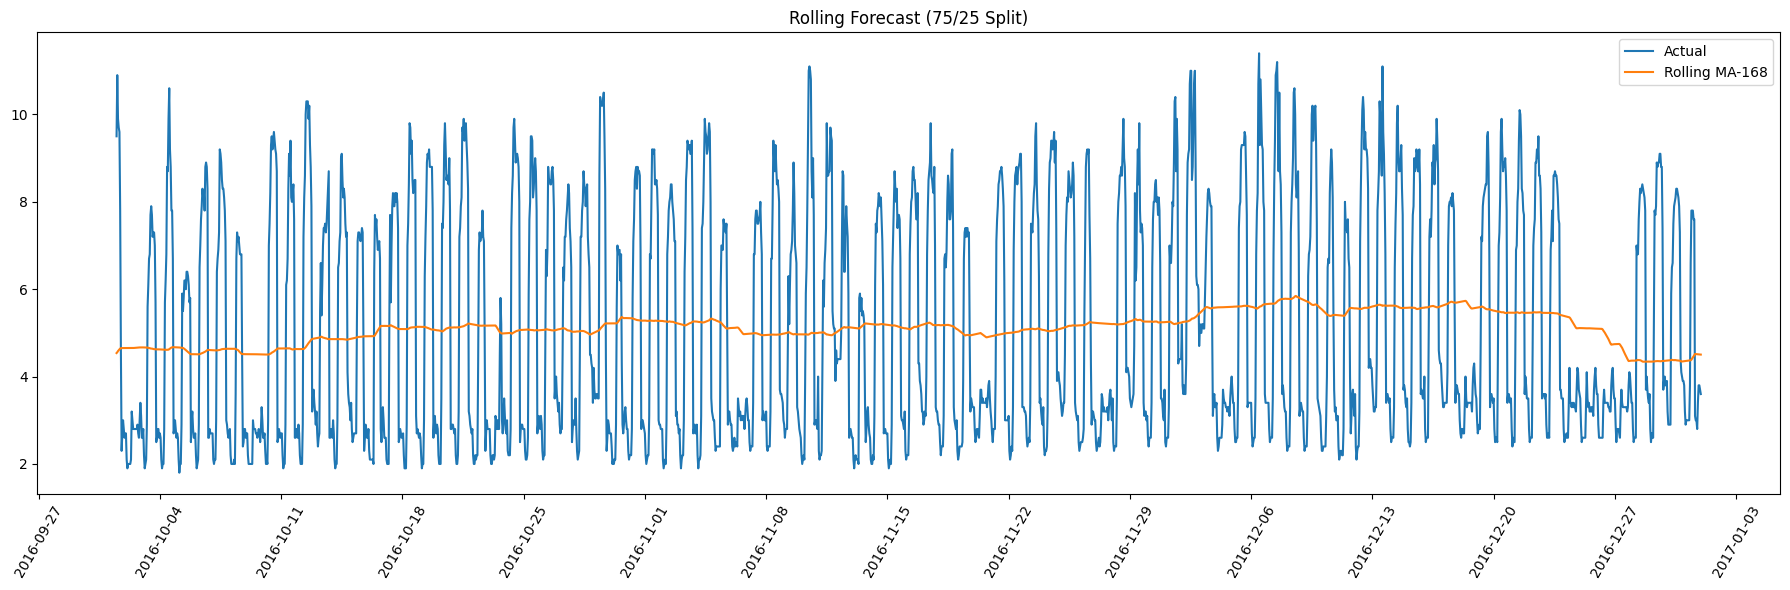

In [150]:
import matplotlib.dates as mdates



test.index = pd.to_datetime(test.index)



plt.figure(figsize=(18, 6))

plt.plot(test.index, test["meter_reading"], label="Actual")
plt.plot(test.index, predictions, label="Rolling MA-168")
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=60)
plt.legend()
plt.title("Rolling Forecast (75/25 Split)")
plt.tight_layout()
plt.show()

## Loading EnergyTTM

In [151]:

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
args = {
    "num_input_channels": 1,
    "context_length": 168,  # 1 week of hourly data
    "prediction_length": 24,   # Forecasting next 24 hours
    "patch_stride": 24,
}


# -------------------------------------------------------
# Initialize Model
# -------------------------------------------------------

model = TinyTimeMixerForPrediction.from_pretrained(
    "EnergyFM/energy-ttm",  # Name of the model on Hugging Face
    revision="168-24-comm",
    num_input_channels=1,  # tsp.num_input_channels 
).to(device)

#### Helper Function for Pre-processing and Evaluation

In [152]:

def standardize_series(series, eps=1e-8):
    mean = np.mean(series)
    std = np.std(series)
    standardized_series = (series - mean) / (std+eps)
    return standardized_series, mean, std

def unscale_predictions(predictions, mean, std, eps=1e-8):
    return predictions * (std+eps) + mean




### Custom Torch Dataset for EnergyTTM

In [153]:

class TimeSeriesDataset(Dataset):
    def __init__(self, data, backcast_length, forecast_length, stride=1):
        # Standardize the time series data
        self.data, self.mean, self.std = standardize_series(data)
        self.backcast_length = backcast_length
        self.forecast_length = forecast_length
        self.stride = stride

    def __len__(self):
        return (len(self.data) - self.backcast_length - self.forecast_length) // self.stride + 1

    def __getitem__(self, index):
        start_index = index * self.stride
        x = self.data[start_index : start_index + self.backcast_length]
        y = self.data[start_index + self.backcast_length : start_index + self.backcast_length + self.forecast_length]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


In [154]:
def create_dataset_if_valid(energy_data, args):
    """
    Create a TimeSeriesDataset if the series length is sufficient.

    Parameters:
        energy_data (np.array): Cleaned energy time series.
        args (dict): Configuration containing:
                     - context_length
                     - prediction_length
                     - patch_stride

    Returns:
        TimeSeriesDataset or None: Dataset object if valid, otherwise None.
    """
    # Minimum required length to form at least one training sample
    min_required = args["context_length"] + args["prediction_length"]

    # Skip if series is too short
    if len(energy_data) < min_required:
        print("   Too short, skipping...")
        return None

    # Create dataset using sliding windows
    dataset = TimeSeriesDataset(
        energy_data,
        args["context_length"],
        args["prediction_length"],
        args["patch_stride"]
    )

    # Ensure dataset contains at least one sample
    if len(dataset) == 0:
        print("   No samples, skipping...")
        return None

    return dataset



#### Intialising Train and Test Dataset

In [155]:
test_dataset = create_dataset_if_valid(test["meter_reading"].values, args)  
train_dataset = create_dataset_if_valid(train["meter_reading"].values, args=args)
print("Test dataset size:", len(test_dataset))
print("Train dataset size:", len(train_dataset))
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

Test dataset size: 84
Train dataset size: 267


In [156]:

## Applying transfer learning setup 

# -----------------------------------------------------
# Freeze everything
# -----------------------------------------------------
for param in model.parameters():
    param.requires_grad = False

# -----------------------------------------------------
# Unfreeze prediction layers
# -----------------------------------------------------
trainable_layers = []

for name, param in model.named_parameters():

    lname = name.lower()

    if (
        "head" in lname
        or "decoder" in lname
        or "prediction" in lname
    ):

        param.requires_grad = True
        trainable_layers.append(name)

# =====================================================
# PRINT TRAINABLE LAYERS
# =====================================================
print("\nTrainable layers:")

for layer in trainable_layers:
    print(layer)

# =====================================================
# PARAM COUNT
# =====================================================
trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in model.parameters()
)

print(
    f"\nTrainable params: "
    f"{trainable:,} / {total:,} "
    f"({100 * trainable / total:.4f}%)"
)

# -------------------------------------------------------
# Define Loss Function
# -------------------------------------------------------
# Mean Squared Error for forecasting evaluation
criterion = torch.nn.MSELoss()


import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-5)



Trainable layers:
decoder.adapter.weight
decoder.adapter.bias
decoder.decoder_block.mixers.0.patch_mixer.norm.norm.weight
decoder.decoder_block.mixers.0.patch_mixer.norm.norm.bias
decoder.decoder_block.mixers.0.patch_mixer.mlp.fc1.weight
decoder.decoder_block.mixers.0.patch_mixer.mlp.fc1.bias
decoder.decoder_block.mixers.0.patch_mixer.mlp.fc2.weight
decoder.decoder_block.mixers.0.patch_mixer.mlp.fc2.bias
decoder.decoder_block.mixers.0.patch_mixer.gating_block.attn_layer.weight
decoder.decoder_block.mixers.0.patch_mixer.gating_block.attn_layer.bias
decoder.decoder_block.mixers.0.feature_mixer.norm.norm.weight
decoder.decoder_block.mixers.0.feature_mixer.norm.norm.bias
decoder.decoder_block.mixers.0.feature_mixer.mlp.fc1.weight
decoder.decoder_block.mixers.0.feature_mixer.mlp.fc1.bias
decoder.decoder_block.mixers.0.feature_mixer.mlp.fc2.weight
decoder.decoder_block.mixers.0.feature_mixer.mlp.fc2.bias
decoder.decoder_block.mixers.0.feature_mixer.gating_block.attn_layer.weight
decoder.dec

## Finetuning EnergyTTM

In [157]:
num_epochs = 20
criterion = torch.nn.MSELoss()

for epoch in range(num_epochs):

    model.train()   # Enable training mode
    train_losses = []

    for x_train, y_train in train_loader:

        # Add channel dimension if needed
        x_train = x_train.unsqueeze(-1).to(device)
        y_train = y_train.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        # print(x_train)
        output = model(x_train)
        # print(output)
        # break
        forecast = output.prediction_outputs.squeeze(-1)

        # Compute loss
        loss = criterion(forecast, y_train)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        train_losses.append(loss.item())

    avg_train_loss = sum(train_losses) / len(train_losses)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.6f}")


Epoch [1/20] Train Loss: 0.295116
Epoch [2/20] Train Loss: 0.321114
Epoch [3/20] Train Loss: 0.291168
Epoch [4/20] Train Loss: 0.317740
Epoch [5/20] Train Loss: 0.297838
Epoch [6/20] Train Loss: 0.299421
Epoch [7/20] Train Loss: 0.313686
Epoch [8/20] Train Loss: 0.301870
Epoch [9/20] Train Loss: 0.296688
Epoch [10/20] Train Loss: 0.289667
Epoch [11/20] Train Loss: 0.305026
Epoch [12/20] Train Loss: 0.324979
Epoch [13/20] Train Loss: 0.311219
Epoch [14/20] Train Loss: 0.304992
Epoch [15/20] Train Loss: 0.292333
Epoch [16/20] Train Loss: 0.305754
Epoch [17/20] Train Loss: 0.299883
Epoch [18/20] Train Loss: 0.303440
Epoch [19/20] Train Loss: 0.315869
Epoch [20/20] Train Loss: 0.310591


### Inferencing on Test dataset

In [158]:

model.eval()

val_losses = []
y_true_test = []
y_pred_test = []

# Iterate over dataset one sample at a time
for x_test, y_test in test_loader:

    # Add channel dimension and move to device
    x_test = x_test.unsqueeze(-1).to(device)
    y_test = y_test.to(device)

    with torch.no_grad():
        # Forward pass
        output = model(x_test)
        forecast = output.prediction_outputs.squeeze(-1)

        # Compute loss
        loss = criterion(forecast, y_test)

        # Skip if loss is NaN
        if torch.isnan(loss):
            continue

        # Store results
        val_losses.append(loss.item())
        y_true_test.append(y_test.cpu().numpy())
        y_pred_test.append(forecast.cpu().numpy())

# If no valid predictions collected
if len(y_true_test) == 0:
    y_true_test = np.array([])
    y_pred_test = np.array([])

# Concatenate predictions and ground truth
y_true = np.concatenate(y_true_test, axis=0)
y_pred = np.concatenate(y_pred_test, axis=0)



In [159]:
mean = test_dataset.mean
std  = test_dataset.std

y_true_flat = y_true.reshape(-1)
y_pred_flat = y_pred.reshape(-1)


y_true_unscaled = unscale_predictions(y_true_flat, mean, std)
y_pred_unscaled = unscale_predictions(y_pred_flat, mean, std)


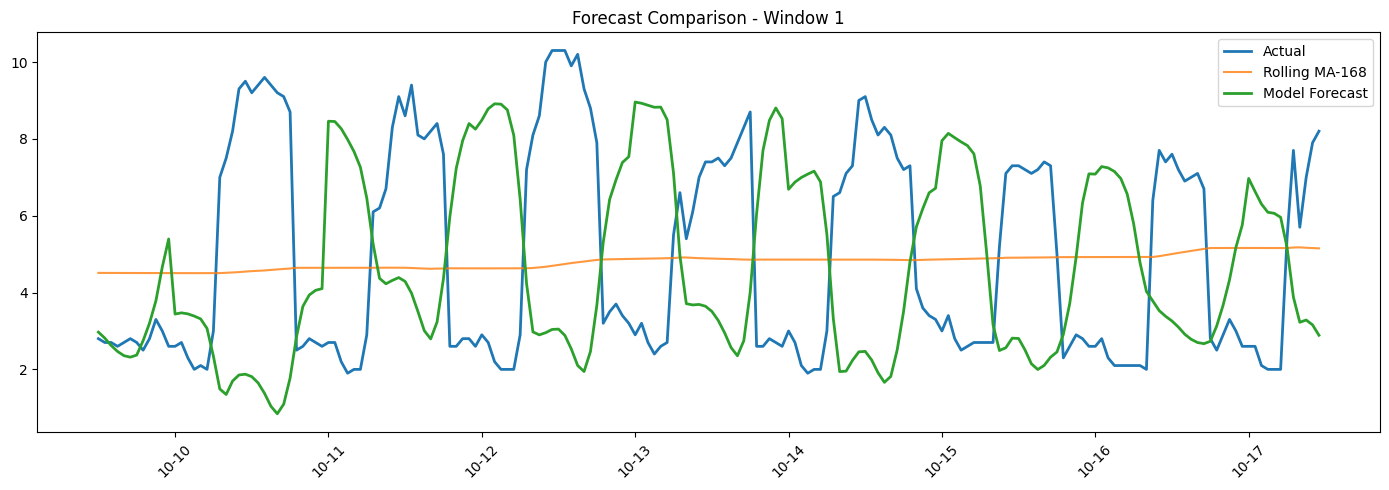

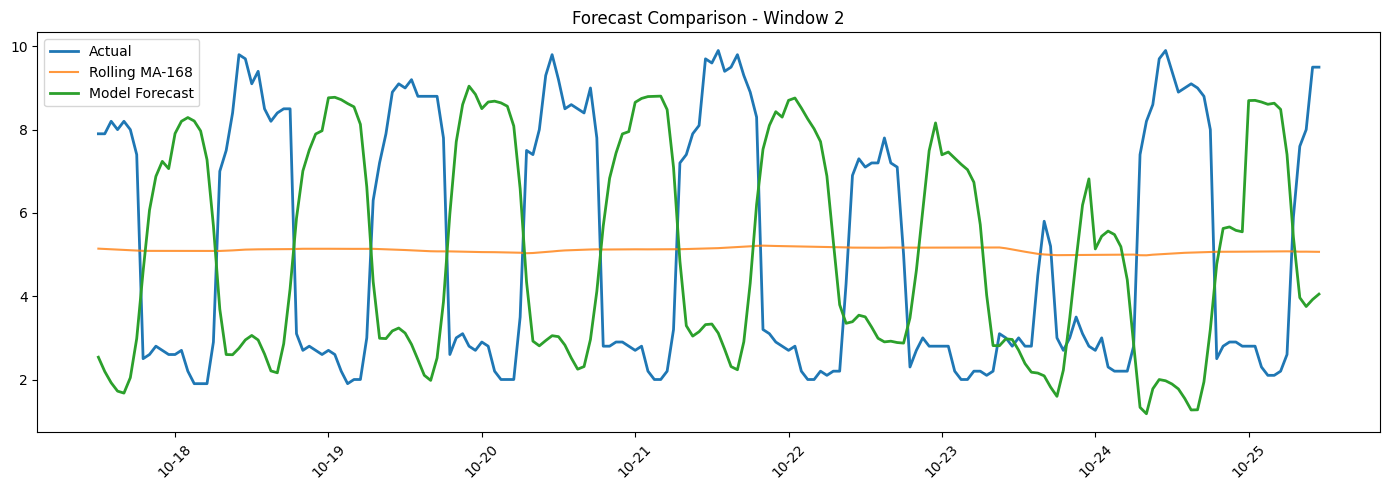

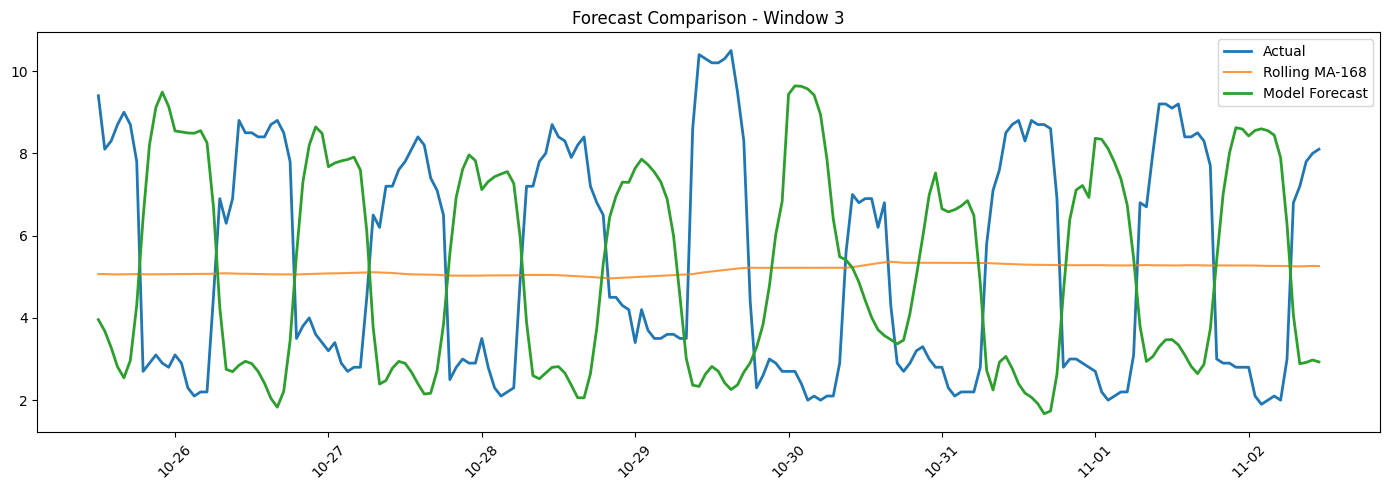

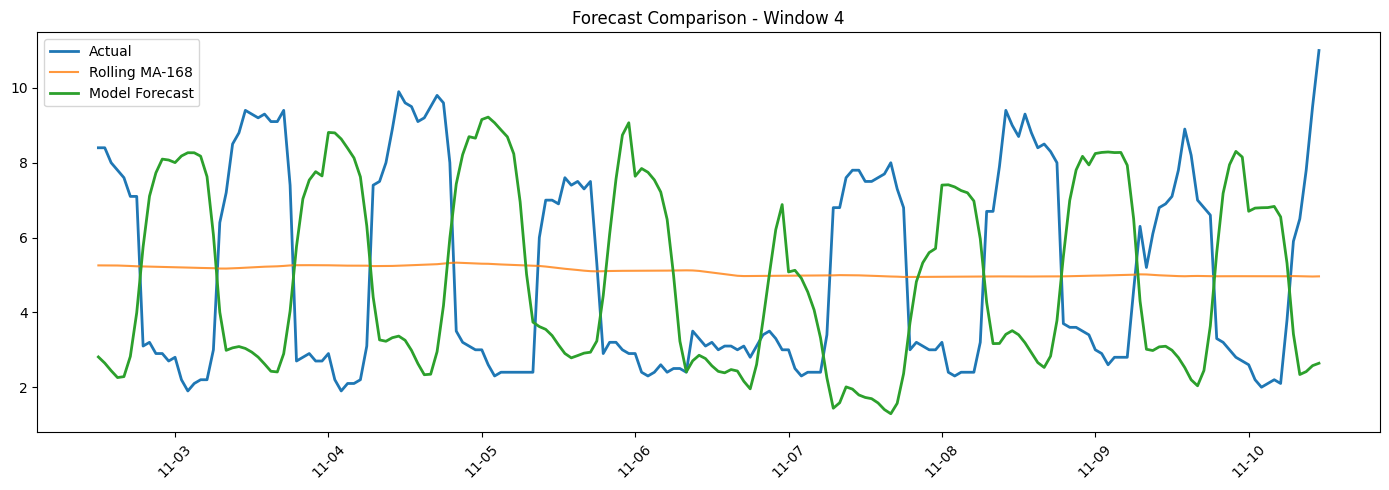

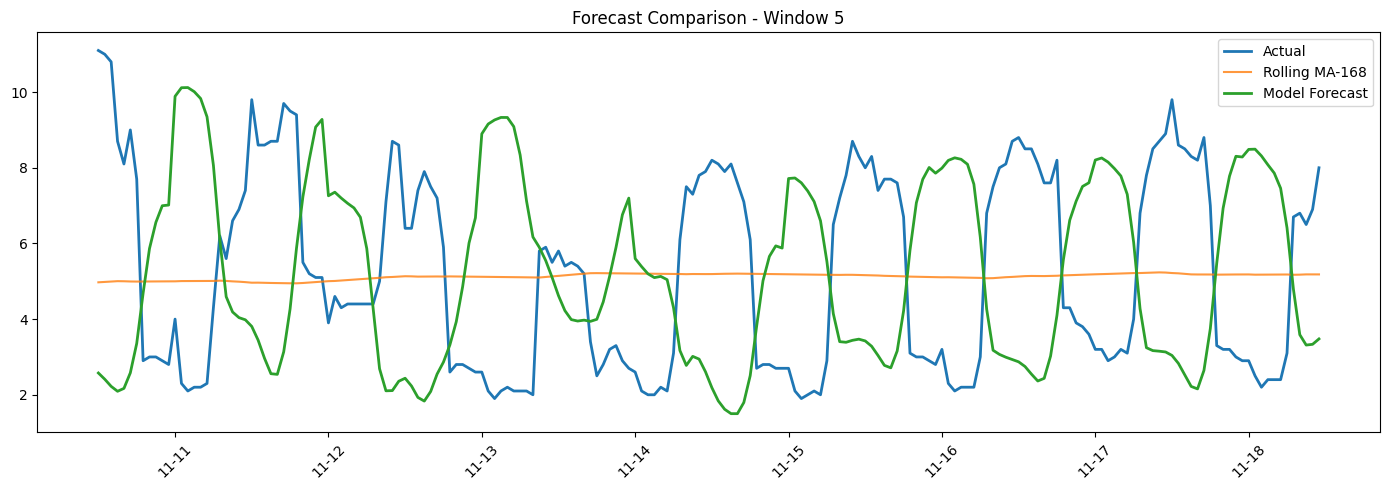

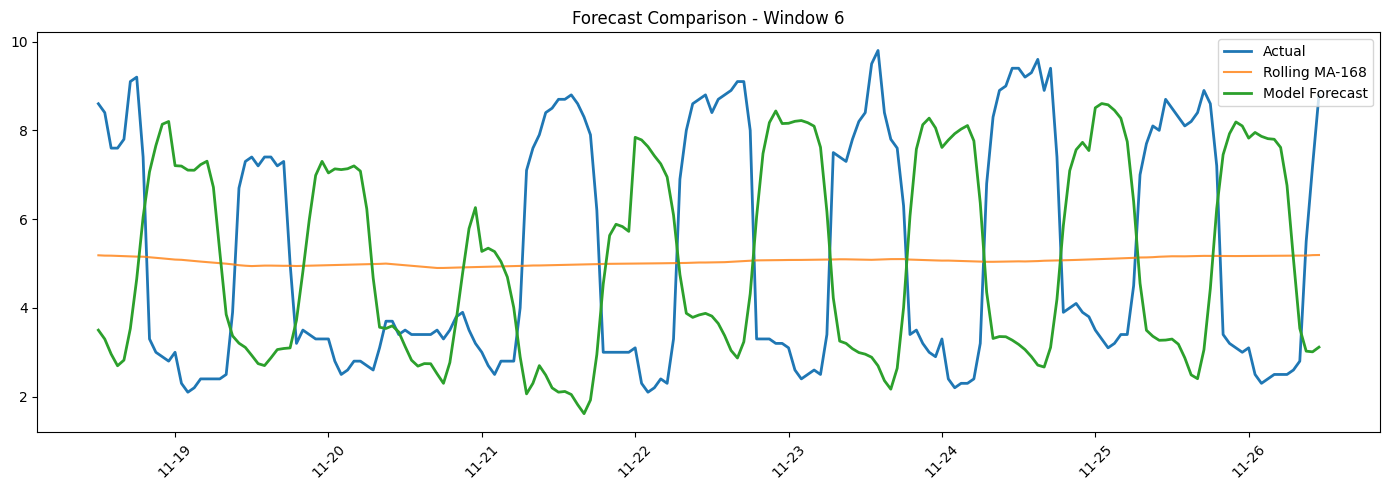

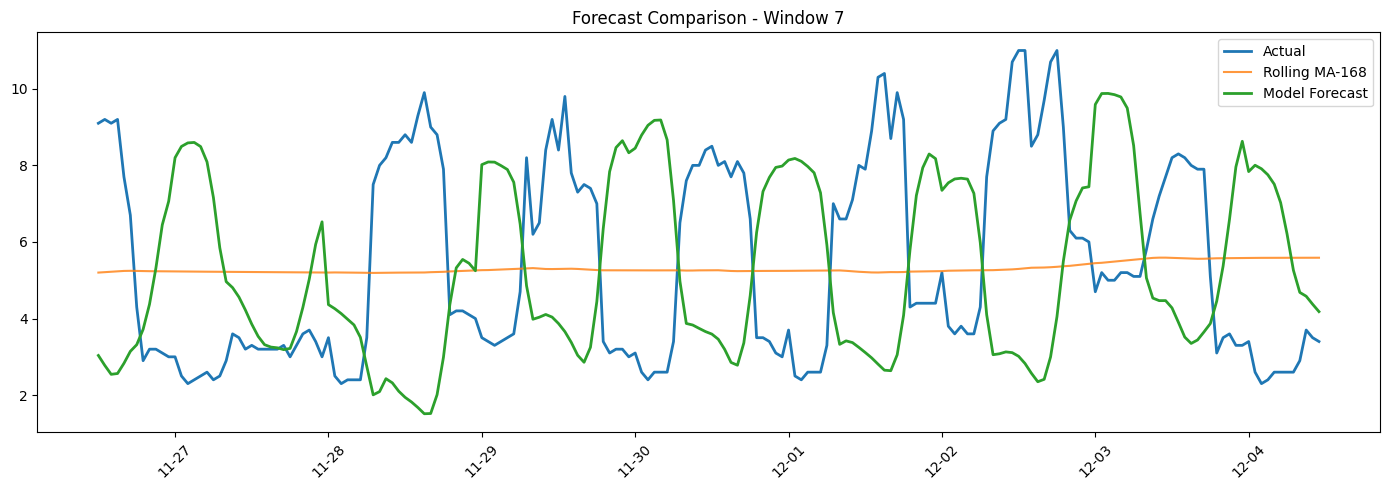

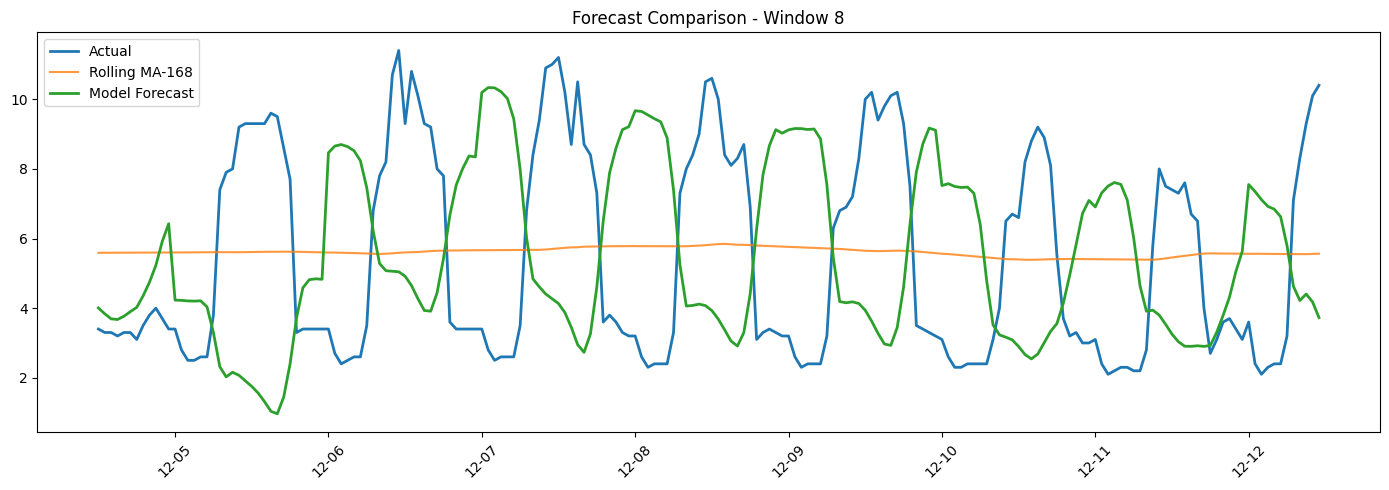

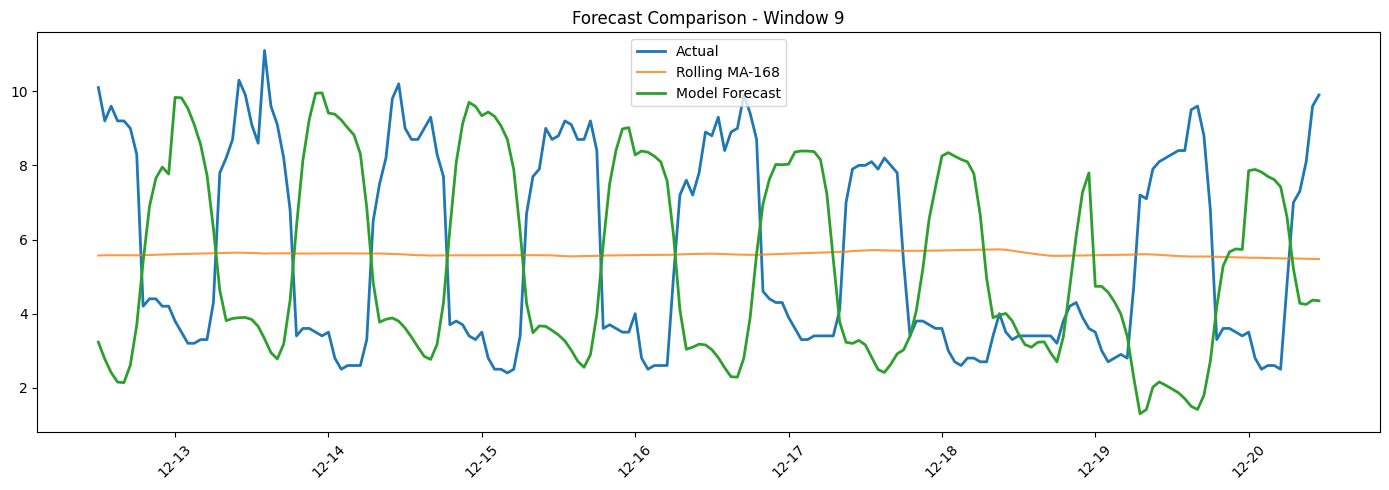

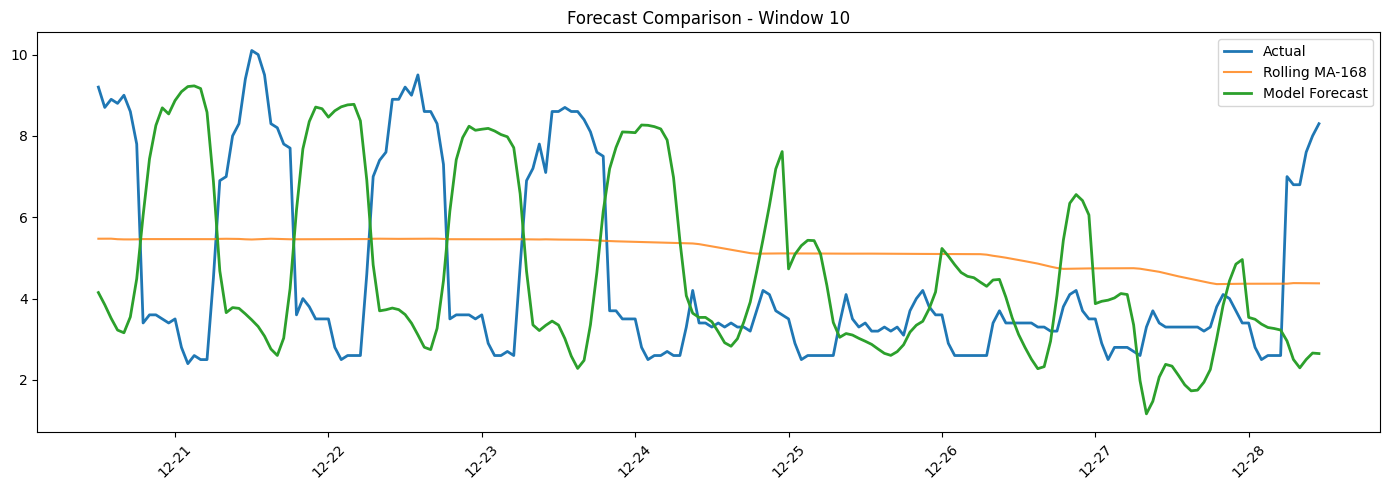

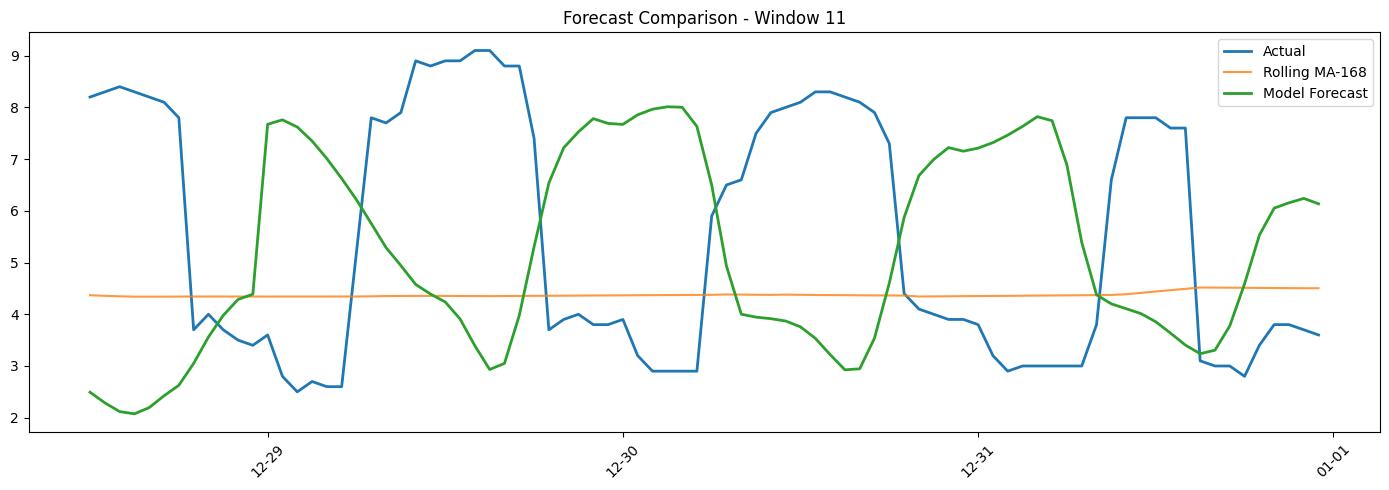

In [160]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# No lag correction
model_time_index = test.index[-len(y_pred_unscaled):]

days_per_plot = 8
points_per_plot = days_per_plot * 24

n_points = len(test)
n_plots = int(np.ceil(n_points / points_per_plot))

# Skip first window
for i in range(1, n_plots):

    start = i * points_per_plot
    end = min((i + 1) * points_per_plot, n_points)

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(
        test.index[start:end],
        test["meter_reading"].iloc[start:end],
        label="Actual",
        linewidth=2
    )

    ax.plot(
        test.index[start:end],
        predictions[start:end],
        label="Rolling MA-168",
        alpha=0.8
    )

    mask = (
        (model_time_index >= test.index[start]) &
        (model_time_index <= test.index[end - 1])
    )

    ax.plot(
        model_time_index[mask],
        np.asarray(y_pred_unscaled)[mask],
        label="Model Forecast",
        linewidth=2
    )

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

    plt.xticks(rotation=45)
    plt.title(f"Forecast Comparison - Window {i}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [161]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Flatten just to be safe
y_true_unscaled_flat = y_true_unscaled.reshape(-1)
y_pred_unscaled_flat = y_pred_unscaled.reshape(-1)

mae_unscaled = mean_absolute_error(
    y_true_unscaled_flat,
    y_pred_unscaled_flat
)

rmse_unscaled = np.sqrt(
    mean_squared_error(
        y_true_unscaled_flat,
        y_pred_unscaled_flat
    )
)

print(f" MAE  : {mae_unscaled:.4f}")
print(f" RMSE : {rmse_unscaled:.4f}")

 MAE  : 0.9068
 RMSE : 1.2205
